# 🤖 강화학습(Reinforcement Learning) 실습
## GridWorld로 배우는 RL 기초: Policy Iteration · SARSA · Q-Learning

---

이 실습에서는 **GridWorld** 환경을 통해 강화학습의 핵심 알고리즘을 직접 실습합니다.
모든 셀을 **위에서부터 순서대로** 실행하면 됩니다.

▶ 버튼 또는 `Shift+Enter`를 눌러 실행하세요.

### 📋 실습 목차

| 단계 | 알고리즘 | 분류 | 특징 |
|:----:|----------|------|------|
| Part 1 | **Policy Iteration** | Dynamic Programming | 환경에 대한 정보(model) 필요 |
| Part 2 | **SARSA** | Model-Free · On-Policy | 행동을 직접 수행하며 현재 정책을 기준으로 학습 |
| Part 3 | **Q-Learning** | Model-Free · Off-Policy | 행동을 직접 수행하며 최선의 행동을 기준으로 학습 |
| Part 4 | **Cliff World** | SARSA vs Q-Learning 비교 | 각 방법의 경로 차이가 왜 발생할까? |

---

### 🗺️ GridWorld 규칙

```
┌──────────────────────────────────────────────────────────┐
│  A  (파란 원)   에이전트 현재 위치                        │
│  ★  (초록 칸)   목표 지점 ─ 도달하면 +100점, 게임 종료   │
│  ✕  (빨간 칸)   함정      ─ 밟으면  -100점, 게임 종료   │
│  ■  (회색 칸)   벽        ─ 이동 불가 (제자리 유지)       │
│     (흰색 칸)   일반 칸   ─ 이동할 때마다 -1점            │
└──────────────────────────────────────────────────────────┘
```

> 💡 **목표**: 최소한의 이동으로 함정을 피해 목표 지점에 도달하는 최적 경로를 도출하는 것입니다.


In [ ]:
# ============================================================
# 📦 필요한 라이브러리 불러오기 (Import Libraries)
# ============================================================
# 이 셀을 가장 먼저 실행하세요.
# Colab 기본 환경에 포함된 라이브러리만 사용하므로 별도 설치가 필요 없습니다.
# ============================================================

import numpy as np                          # 수치 계산 (Numerical Computing)
import matplotlib.pyplot as plt            # 시각화 (Visualization)
import matplotlib.patches as patches       # 도형 그리기 (Shapes)
from matplotlib.colors import Normalize   # 색상 정규화 (Value Heatmap)
from matplotlib import cm                  # Colormap
import random                              # 랜덤 샘플링
from collections import defaultdict        # Q-table 자료구조
from enum import Enum                      # 열거형 (TileType, Action)
import copy                                # 딥카피 (Policy 비교용)
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi']         = 100    # 그림 해상도

print("✅ 라이브러리 로드 완료! 다음 셀을 실행하세요.")


✅ 라이브러리 로드 완료! 다음 셀을 실행하세요.


In [ ]:
# ============================================================
# 🌍 GridWorld 환경 정의 (Environment)
# ============================================================
# 원본 코드(gridworld_env.py)에서 pygame 의존성을 제거하고
# Colab에서 바로 실행 가능하도록 수정했습니다.
# ============================================================

class TileType(Enum):
    """각 격자 칸(tile)의 종류를 정의합니다."""
    NORMAL = 0  # 일반 칸: 이동 가능, 보상 -1
    WALL   = 1  # 벽: 이동 불가 (이동 시도 시 제자리)
    TRAP   = 2  # 함정: 보상 -100 후 에피소드 종료
    GOAL   = 3  # 목표: 보상 +100 후 에피소드 종료


class Action(Enum):
    """에이전트가 취할 수 있는 4가지 행동(Action)을 정의합니다."""
    UP    = 0  # 위로 이동 (row - 1)
    DOWN  = 1  # 아래로 이동 (row + 1)
    LEFT  = 2  # 왼쪽으로 이동 (col - 1)
    RIGHT = 3  # 오른쪽으로 이동 (col + 1)


# ── 6×6 기본 맵 데이터 (map_6.json 내용을 코드로 직접 정의) ──
MAP_6 = {
    "width":  6,
    "height": 6,
    "walls":  [[0,1],[0,3],[1,1],[2,3],[3,1],[4,4],[5,1]],
    "traps":  [[1,3],[2,4],[4,3]],
    "goal":   [5, 5]
}


class GridWorldEnv:
    """
    GridWorld 환경 클래스
    ─────────────────────────────────────────────────────────
    강화학습 환경의 기본 인터페이스를 제공합니다.

    사용 방법:
        env   = GridWorldEnv(map_data=MAP_6)
        state = env.reset()                   # 에피소드 시작
        state, reward, done = env.step(action) # 행동 실행
    ─────────────────────────────────────────────────────────
    """

    def __init__(self, map_data=None, width=6, height=6):
        if map_data:
            self._load_from_dict(map_data)
        else:
            self.width  = width
            self.height = height
            self.grid   = np.full((height, width), TileType.NORMAL)
            self._place_special_tiles()

        self.agent_pos = [0, 0]
        self.done      = False

    def _load_from_dict(self, data):
        """딕셔너리 형식의 맵 데이터를 로드합니다."""
        self.width  = data["width"]
        self.height = data["height"]
        self.grid   = np.full((self.height, self.width), TileType.NORMAL)
        for y, x in data.get("walls", []):
            self.grid[y][x] = TileType.WALL
        for y, x in data.get("traps", []):
            self.grid[y][x] = TileType.TRAP
        gy, gx = data["goal"]
        self.grid[gy][gx] = TileType.GOAL

    def _place_special_tiles(self):
        """랜덤 맵 생성 시 벽과 함정을 배치합니다."""
        num_walls = (self.width * self.height) // 5
        num_traps = (self.width * self.height) // 10
        avoid     = {(0, 0), (self.height - 1, self.width - 1)}
        positions = [(i, j) for i in range(self.height) for j in range(self.width)
                     if (i, j) not in avoid]
        random.shuffle(positions)
        for _ in range(num_walls):
            y, x = positions.pop(); self.grid[y][x] = TileType.WALL
        for _ in range(num_traps):
            y, x = positions.pop(); self.grid[y][x] = TileType.TRAP
        self.grid[self.height - 1][self.width - 1] = TileType.GOAL

    def reset(self):
        """에피소드를 초기화하고 시작 위치를 반환합니다."""
        self.agent_pos = [0, 0]
        self.done      = False
        return self.agent_pos[:]

    def step(self, action):
        """
        행동을 실행하고 결과를 반환합니다.

        Parameters
        ----------
        action : int or Action  실행할 행동

        Returns
        -------
        next_state : list   다음 상태 위치 [y, x]
        reward     : int    받은 보상
        done       : bool   에피소드 종료 여부
        """
        if self.done:
            return self.agent_pos[:], 0, True

        dy, dx = {
            Action.UP:    (-1,  0),
            Action.DOWN:  ( 1,  0),
            Action.LEFT:  ( 0, -1),
            Action.RIGHT: ( 0,  1)
        }[Action(action)]

        ny = self.agent_pos[0] + dy
        nx = self.agent_pos[1] + dx

        # 경계 확인 및 벽 충돌 처리 (벽이면 제자리)
        if (0 <= ny < self.height and 0 <= nx < self.width
                and self.grid[ny][nx] != TileType.WALL):
            self.agent_pos = [ny, nx]

        tile   = self.grid[self.agent_pos[0]][self.agent_pos[1]]
        reward = -1  # 기본 이동 비용 (최단 경로 유도)

        if   tile == TileType.TRAP: reward, self.done = -100, True
        elif tile == TileType.GOAL: reward, self.done =  100, True

        return self.agent_pos[:], reward, self.done


# ── 테스트 ────────────────────────────────────────────────────
_env_test = GridWorldEnv(map_data=MAP_6)
n_states  = sum(1 for y in range(_env_test.height)
                for x in range(_env_test.width)
                if _env_test.grid[y][x] != TileType.WALL)
print(f"✅ 환경 생성 완료: {_env_test.width}×{_env_test.height} GridWorld")
print(f"   유효 상태 수 (벽 제외): {n_states}개")


✅ 환경 생성 완료: 6×6 GridWorld
   유효 상태 수 (벽 제외): 29개


In [ ]:
# ============================================================
# 🧩 MDP (Markov Decision Process) 모델 정의
# ============================================================
# Policy Iteration은 환경의 전이 함수(Transition Function)를
# 미리 알고 있어야 합니다. GridWorldMDP가 그 역할을 합니다.
# (SARSA, Q-Learning에서는 사용하지 않습니다.)
# ============================================================

class GridWorldMDP:
    """
    GridWorld를 MDP(마코프 결정 과정)로 모델링하는 클래스

    MDP = (S, A, T, R, γ) 다섯 요소로 구성됩니다:
    ─────────────────────────────────────────────────────────
    S  (States)     : 모든 가능한 상태 — 격자 위의 위치 (y, x)
    A  (Actions)    : 가능한 행동    — UP / DOWN / LEFT / RIGHT
    T  (Transition) : 전이 함수      — P(s' | s, a)
                      ※ 이 환경은 결정론적(deterministic)이므로
                        각 (s, a)에 대해 단 하나의 s'만 존재합니다.
    R  (Reward)     : 보상 함수      — R(s, a, s')
    γ  (Gamma)      : 할인율         — 미래 보상을 현재 가치로 환산
    ─────────────────────────────────────────────────────────
    """

    def __init__(self, env):
        self.env     = env
        self.height  = env.height
        self.width   = env.width
        self.actions = list(Action)

        # 벽(WALL)이 아닌 모든 칸이 상태(state)로 정의됩니다
        self.states = [
            (y, x)
            for y in range(self.height)
            for x in range(self.width)
            if env.grid[y][x] != TileType.WALL
        ]

    def get_transition(self, state, action):
        """
        (state, action) 쌍에 대한 결정론적 전이를 반환합니다.

        Returns
        -------
        next_state : tuple  다음 상태 (y, x)
        reward     : int    전이 보상
        done       : bool   에피소드 종료 여부
        """
        y, x = state
        dy, dx = {
            Action.UP:    (-1,  0),
            Action.DOWN:  ( 1,  0),
            Action.LEFT:  ( 0, -1),
            Action.RIGHT: ( 0,  1)
        }[action]

        ny, nx = y + dy, x + dx

        # 경계 초과 → 제자리
        if not (0 <= ny < self.height and 0 <= nx < self.width):
            return state, -1, False

        tile = self.env.grid[ny][nx]
        if   tile == TileType.WALL: return state,     -1, False
        elif tile == TileType.TRAP: return (ny, nx), -100, True
        elif tile == TileType.GOAL: return (ny, nx),  100, True
        else:                       return (ny, nx),   -1, False


print("✅ GridWorldMDP 클래스 정의 완료")


✅ GridWorldMDP 클래스 정의 완료


📍 6×6 GridWorld 맵 미리보기


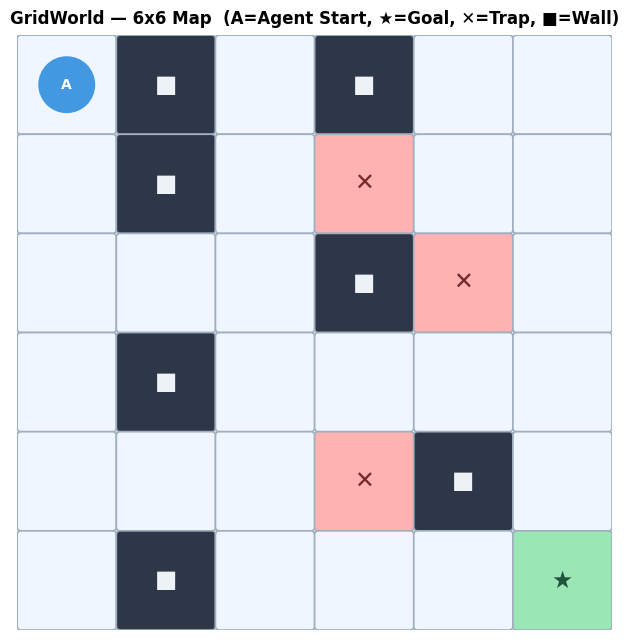

In [ ]:
# ============================================================
# 🎨 시각화 함수 정의 (Visualization — matplotlib 기반)
# ============================================================
# pygame 없이 Colab 셀 안에서 바로 GridWorld를 렌더링합니다.
# ============================================================

# ── 타일 배경색 ────────────────────────────────────────────
TILE_BG = {
    TileType.NORMAL: '#EFF6FF',   # 연한 파랑 (일반)
    TileType.WALL:   '#2D3748',   # 진한 회색 (벽)
    TileType.TRAP:   '#FEB2B2',   # 연한 빨강 (함정)
    TileType.GOAL:   '#9AE6B4',   # 연한 초록 (목표)
}

# ── 타일 아이콘 및 색상 ─────────────────────────────────────
TILE_ICONS  = {TileType.WALL: '■', TileType.TRAP: '✕', TileType.GOAL: '★'}
ICON_COLORS = {TileType.WALL: '#EDF2F7', TileType.TRAP: '#742A2A', TileType.GOAL: '#22543D'}

# ── Policy 화살표 ───────────────────────────────────────────
ARROWS = {Action.UP: '↑', Action.DOWN: '↓', Action.LEFT: '←', Action.RIGHT: '→'}


def render_grid(env, ax, V=None, policy=None, agent_pos=None,
                title="GridWorld", show_value=True, show_policy=True,
                cmap='YlOrRd'):
    """
    GridWorld를 matplotlib Axes에 그립니다.

    Parameters
    ----------
    env         : GridWorldEnv
    ax          : matplotlib Axes
    V           : Value function  {(y,x): float}   — 배경 heatmap
    policy      : Policy          {(y,x): Action}  — 화살표 표시
    agent_pos   : 에이전트 위치   [y, x]
    title       : 제목
    show_value  : Value 숫자 표시 여부 (일반 칸만)
    show_policy : Policy 화살표 표시 여부 (일반 칸만)
    cmap        : Value heatmap 컬러맵
    """
    h, w = env.height, env.width
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)   # y축 뒤집기 (행렬 방향 일치)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.axis('off')

    # Value heatmap 정규화
    valid_vals = []
    if V:
        valid_vals = [v for (y, x), v in V.items()
                      if env.grid[y][x] == TileType.NORMAL]
    norm    = None
    cmap_fn = None
    if valid_vals:
        vmin, vmax = min(valid_vals), max(valid_vals)
        norm    = Normalize(vmin=vmin, vmax=vmax + 1e-9)
        cmap_fn = cm.get_cmap(cmap)

    for y in range(h):
        for x in range(w):
            tile = env.grid[y][x]

            # ── 배경색 결정 ──────────────────────────────
            if tile == TileType.NORMAL and norm and (y, x) in V:
                rgba  = cmap_fn(norm(V[(y, x)]))
                color = rgba            # RGBA tuple
            else:
                color = TILE_BG[tile]

            # ── 셀 사각형 ────────────────────────────────
            rect = patches.FancyBboxPatch(
                (x - 0.46, y - 0.46), 0.92, 0.92,
                boxstyle="round,pad=0.04",
                facecolor=color,
                edgecolor='#A0AEC0',
                linewidth=1.2,
                zorder=1
            )
            ax.add_patch(rect)

            # ── 타일 아이콘 (벽 / 함정 / 목표) ──────────
            if tile in TILE_ICONS:
                ax.text(x, y, TILE_ICONS[tile],
                        ha='center', va='center',
                        fontsize=17, color=ICON_COLORS[tile],
                        fontweight='bold', zorder=2)

            # ── Value 값 텍스트 (일반 칸만) ─────────────
            if show_value and V and (y, x) in V and tile == TileType.NORMAL:
                ax.text(x, y + 0.27, f'{V[(y, x)]:.1f}',
                        ha='center', va='center',
                        fontsize=7.5, color='#2D3748', zorder=3)

            # ── Policy 화살표 (일반 칸만) ────────────────
            if show_policy and policy and (y, x) in policy and tile == TileType.NORMAL:
                ax.text(x, y - 0.1, ARROWS[policy[(y, x)]],
                        ha='center', va='center',
                        fontsize=15, color='#2B6CB0',
                        fontweight='bold', zorder=3)

    # ── 에이전트 ────────────────────────────────────────
    if agent_pos:
        ay, ax_ = agent_pos
        circle = plt.Circle((ax_, ay), 0.28, color='#4299E1', zorder=4)
        ax.add_patch(circle)
        ax.text(ax_, ay, 'A', ha='center', va='center',
                fontsize=10, color='white', fontweight='bold', zorder=5)

    # ── 격자선 ──────────────────────────────────────────
    for i in range(h + 1):
        ax.axhline(i - 0.5, color='#E2E8F0', linewidth=0.5, zorder=0)
    for j in range(w + 1):
        ax.axvline(j - 0.5, color='#E2E8F0', linewidth=0.5, zorder=0)


def show_gridworld(env, V=None, policy=None, agent_pos=None, title="GridWorld"):
    """GridWorld 단독으로 출력합니다."""
    fig, ax = plt.subplots(figsize=(env.width + 0.5, env.height + 0.5))
    render_grid(env, ax, V=V, policy=policy, agent_pos=agent_pos, title=title)
    plt.tight_layout()
    plt.show()


def show_value_and_policy(env, V, policy, iteration=None):
    """Value Function과 Policy를 좌우로 나란히 표시합니다."""
    fig, axes = plt.subplots(1, 2, figsize=(env.width * 2 + 1, env.height + 0.5))
    suffix = f" — Iter {iteration}" if iteration is not None else ""
    render_grid(env, axes[0], V=V,
                title=f"Value Function{suffix}",
                show_value=True, show_policy=False)
    render_grid(env, axes[1], policy=policy,
                title=f"Policy{suffix}",
                show_value=False, show_policy=True)
    plt.tight_layout()
    plt.show()


# ── 맵 미리보기 ──────────────────────────────────────────────
print("📍 6×6 GridWorld 맵 미리보기")
_env_preview = GridWorldEnv(map_data=MAP_6)
show_gridworld(_env_preview,
               agent_pos=[0, 0],
               title="GridWorld — 6x6 Map  (A=Agent Start, ★=Goal, ✕=Trap, ■=Wall)")


---
# 🔵 Part 1: Policy Iteration

## 핵심 아이디어

Policy Iteration은 **환경의 모든 정보(예: 지도, 전이확률(transition probability) 등)를 알고 있을 때** 사용하는 Dynamic Programming(동적 프로그래밍) 방법입니다.

> 📌 **이해를 돕기위한 예시**: 미로의 완전한 지도가 주어져 있을 때, 모든 경우의 수를 미리 계산해 최적 경로를 찾는 방법입니다.

---

## 주요 개념

### 🔹 Value Function V(s) — 상태 가치 함수
**"지금 이 위치에서 최선을 다했을 때, 앞으로 기대되는 총 보상은 얼마인가?"**

$$V^\pi(s) = \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t r_t \;\bigg|\; s_0 = s,\; \pi \right]$$

- $\gamma$ (gamma, **할인율**): 0에 가까울수록 눈앞의 보상 중시 / 1에 가까울수록 미래 보상도 중시

### 🔹 Policy π(s) — 정책
**"각 상태에서 어떤 행동을 할지 정한 규칙"** → π : S → A

### 🔹 Bellman Equation — 벨만 방정식
현재 상태의 가치를 다음 상태의 가치로 재귀적으로 표현합니다:

$$V^\pi(s) = R(s,\; \pi(s)) \;+\; \gamma \cdot V^\pi(s')$$

- $s$: 상태(state)
- $R$: 보상(reward)
- $\pi(s)$: 현재 상태에서 정책(policy) $\pi$ 에 따른 행동(action)
- $\gamma$: 더 빠른 행동을 학습하기 위해 미래의 보상을 감소시키는 감가율(discount factor)
- $s'$: 다음 상태(next state)

---

## 알고리즘 흐름

```
① 초기 Policy π₀ 설정 (예: 모든 상태에서 RIGHT)
    ↓
② Policy Evaluation
   현재 π 로 V(s) 계산 (Bellman Equation 반복 적용, 수렴까지)
    ↓
③ Policy Improvement
   V(s)를 보고 각 상태에서 더 좋은 행동으로 π 갱신
    ↓
④ π 가 변하지 않으면 → 최적 정책 π* 도달! (수렴)
   변하면 → ②로 돌아가 반복
```


In [ ]:
# ============================================================
# 🔵 Step 1 — Policy Evaluation (정책 평가)
# ============================================================
# 현재 Policy π 가 주어졌을 때, 각 상태의 Value V(s)를 계산합니다.
# Bellman Equation을 수렴할 때까지 반복 적용합니다.
# ============================================================

def policy_evaluation(policy, mdp, gamma=0.95, theta=1e-3):
    """
    현재 정책(policy)에 대한 가치 함수 V(s)를 반복법으로 계산합니다.

    핵심 수식 (Bellman Expectation Equation):
        V(s) ← R(s, π(s)) + γ · V(s')

    Parameters
    ----------
    policy : {state: Action}  평가할 정책
    mdp    : GridWorldMDP     환경 모델 (전이 함수 포함)
    gamma  : float            할인율 (discount factor)  0 < γ < 1
    theta  : float            수렴 판정 기준값  (변화량 < theta 이면 수렴)

    Returns
    -------
    V : {state: float}  수렴된 가치 함수
    """
    # 모든 상태의 Value를 0으로 초기화
    V = {s: 0.0 for s in mdp.states}

    while True:
        delta = 0.0   # 이번 스윕(sweep)에서의 최대 변화량

        for s in mdp.states:
            a = policy[s]   # 현재 정책이 상태 s에서 지정한 행동

            # MDP 전이: (상태, 행동) → (다음 상태, 보상, 종료여부)
            next_s, reward, done = mdp.get_transition(s, a)

            # Bellman Equation 적용
            # ※ done=True 이면 에피소드 종료 → 미래 가치 = 0
            V_new = reward + gamma * V.get(next_s, 0.0) * (not done)

            delta  = max(delta, abs(V[s] - V_new))  # 최대 변화량 추적
            V[s]   = V_new

        # 변화량이 충분히 작으면 수렴으로 판정
        if delta < theta:
            break

    return V


# ============================================================
# 🔵 Step 2 — Policy Improvement (정책 개선)
# ============================================================
# 계산된 V(s)를 바탕으로 각 상태에서 최선의 행동을 다시 찾습니다.
# ============================================================

def policy_improvement(V, mdp, gamma=0.95):
    """
    가치 함수 V(s)를 기반으로 탐욕적(greedy) 정책을 계산합니다.

    각 상태 s에 대해:
        π(s) = argmax_a [ R(s, a) + γ · V(s') ]
              → Q(s, a) 를 최대화하는 행동 선택

    Parameters
    ----------
    V     : {state: float}  현재 가치 함수
    mdp   : GridWorldMDP    환경 모델
    gamma : float           할인율

    Returns
    -------
    policy        : {state: Action}  새로운 탐욕 정책
    policy_stable : bool             정책이 변하지 않았으면 True
    """
    policy        = {}
    policy_stable = True

    for s in mdp.states:
        # 모든 행동에 대해 Q(s, a) 값 계산
        q_values = {}
        for a in mdp.actions:
            next_s, reward, done = mdp.get_transition(s, a)
            q_values[a] = reward + gamma * V.get(next_s, 0.0) * (not done)

        # Q(s, a)가 가장 큰 행동 선택 (greedy)
        best_action = max(q_values, key=q_values.get)
        policy[s]   = best_action

    return policy, policy_stable


print("✅ Policy Evaluation & Improvement 함수 정의 완료")


✅ Policy Evaluation & Improvement 함수 정의 완료


In [ ]:
# ============================================================
# 🔵 Policy Iteration — 메인 알고리즘
# ============================================================
# Policy Evaluation ↔ Policy Improvement 를 번갈아 수행하며
# 최적 정책(Optimal Policy π*)에 수렴합니다.
# ============================================================

def policy_iteration(mdp, gamma=0.95, theta=1e-3, max_iterations=50, verbose=True):
    """
    Policy Iteration 알고리즘

    반복 구조:
        while 정책이 변하는 동안:
            V      ← PolicyEvaluation(π, mdp)   # 현재 정책으로 V 계산
            π      ← PolicyImprovement(V, mdp)  # V 기반으로 π 개선
            if π 변화 없음 → 수렴, 종료

    Parameters
    ----------
    mdp            : GridWorldMDP  환경 모델
    gamma          : float         할인율 (보통 0.9 ~ 0.99)
    theta          : float         Policy Evaluation 수렴 기준값
    max_iterations : int           최대 반복 횟수 (무한 루프 방지)
    verbose        : bool          반복 정보 출력 여부

    Returns
    -------
    V       : {state: float}   최적 가치 함수
    policy  : {state: Action}  최적 정책
    history : list             각 반복의 (V, policy) 스냅샷 (시각화용)
    """
    # ── 초기 Policy: 모든 상태에서 RIGHT ─────────────────────
    # (랜덤 초기화보다 수렴 빠름)
    policy  = {s: Action.RIGHT for s in mdp.states}
    history = []   # 각 iteration 결과 저장 (시각화용)

    for iteration in range(max_iterations):

        # ── Step 1: Policy Evaluation ──────────────────────
        # 현재 정책 π 로 모든 상태의 V(s) 계산
        V = policy_evaluation(policy, mdp, gamma, theta)

        # ── Step 2: Policy Improvement ─────────────────────
        # V(s) 를 보고 각 상태에서 더 좋은 행동으로 π 갱신
        old_policy = policy.copy()
        policy, _  = policy_improvement(V, mdp, gamma)

        # 몇 개 상태에서 행동이 바뀌었는지 확인
        changed = sum(old_policy[s] != policy[s] for s in mdp.states)
        history.append((copy.copy(V), copy.copy(policy)))

        if verbose:
            print(f"  Iter {iteration:2d}  |  변경된 상태 수 (policy changes): {changed:3d}")

        # ── 수렴 판정: Policy 변화가 없으면 최적 달성 ────────
        if changed == 0:
            if verbose:
                print(f"\n✅ 수렴 완료! 총 {iteration + 1}번 반복 후 최적 정책(Optimal Policy) 도달.")
            break

    return V, policy, history


print("✅ Policy Iteration 함수 정의 완료")


✅ Policy Iteration 함수 정의 완료


  Policy Iteration 실행
  Iter  0  |  변경된 상태 수 (policy changes):  26
  Iter  1  |  변경된 상태 수 (policy changes):   8
  Iter  2  |  변경된 상태 수 (policy changes):   7
  Iter  3  |  변경된 상태 수 (policy changes):   5
  Iter  4  |  변경된 상태 수 (policy changes):   5
  Iter  5  |  변경된 상태 수 (policy changes):   3
  Iter  6  |  변경된 상태 수 (policy changes):   1
  Iter  7  |  변경된 상태 수 (policy changes):   0

✅ 수렴 완료! 총 8번 반복 후 최적 정책(Optimal Policy) 도달.

🗺️  최종 결과 시각화


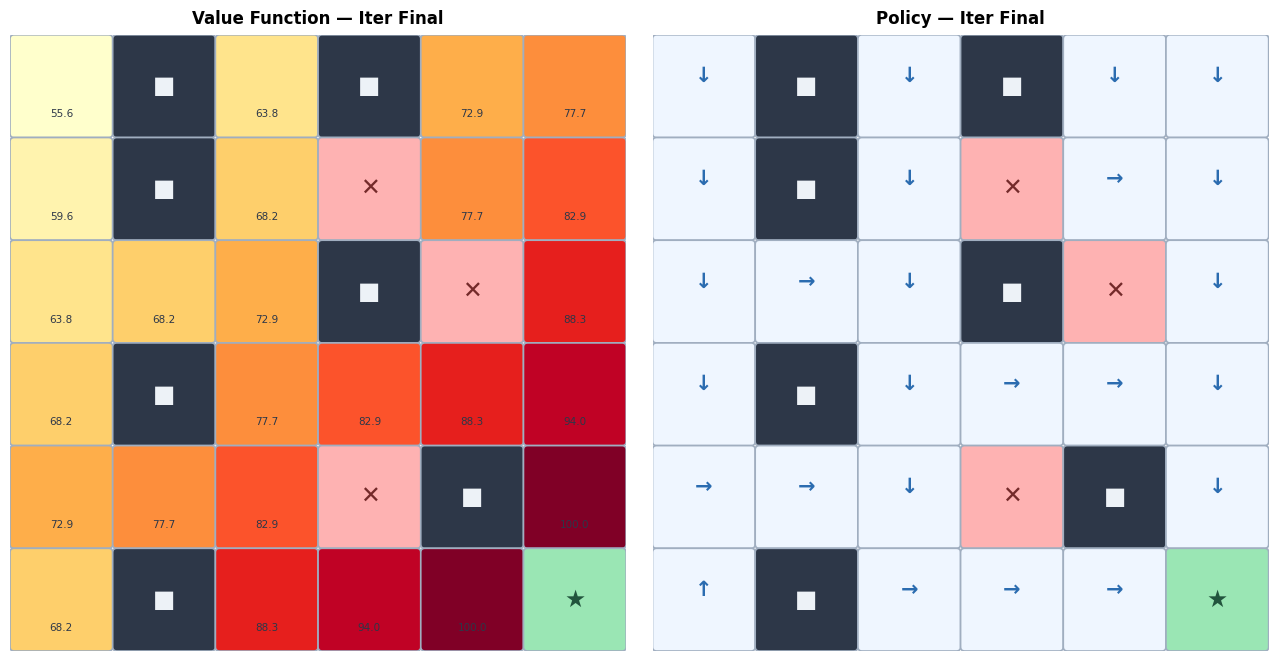

In [ ]:
# ============================================================
# 🚀 Policy Iteration 실행
# ============================================================

print("=" * 55)
print("  Policy Iteration 실행")
print("=" * 55)

env_pi = GridWorldEnv(map_data=MAP_6)
mdp_pi = GridWorldMDP(env_pi)

V_pi, policy_pi, history_pi = policy_iteration(
    mdp_pi,
    gamma          = 0.95,   # 할인율: 미래 보상을 95% 반영
    theta          = 1e-3,   # 수렴 기준: 변화량 0.001 이하
    max_iterations = 50,
    verbose        = True
)

print("\n🗺️  최종 결과 시각화")
show_value_and_policy(env_pi, V_pi, policy_pi, iteration="Final")


총 8번의 반복 결과가 저장되어 있습니다.
초기(0) → 중간 → 최종 순서로 변화 과정을 확인합니다.



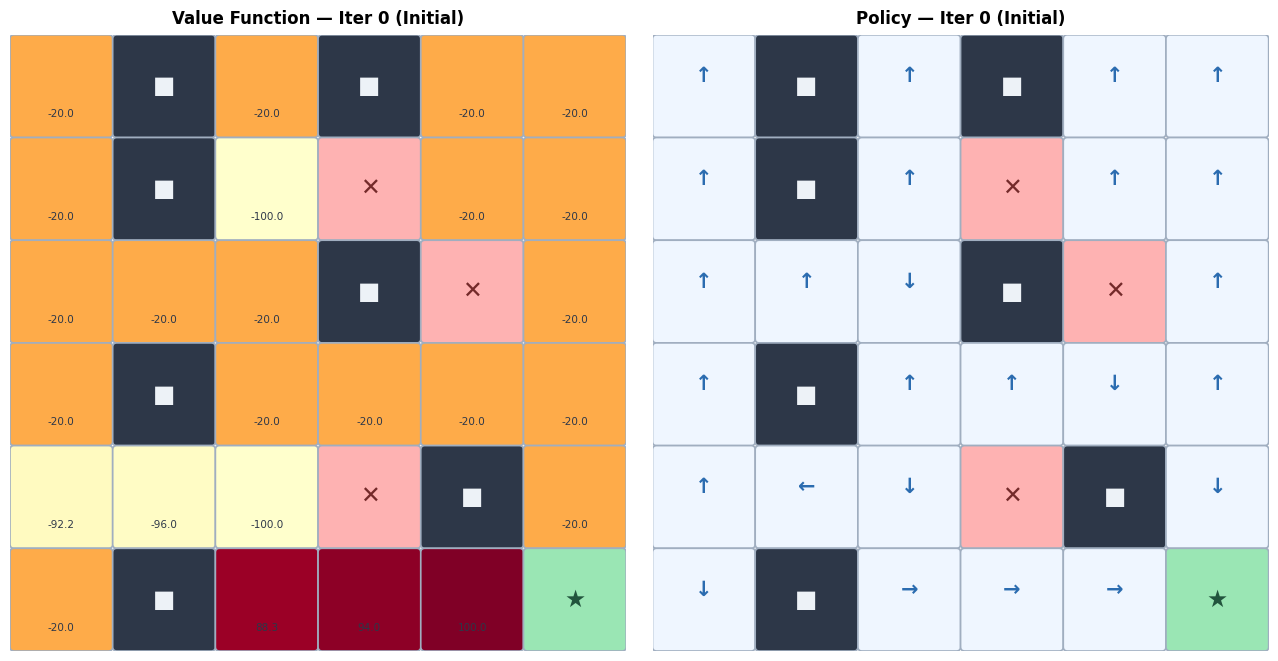

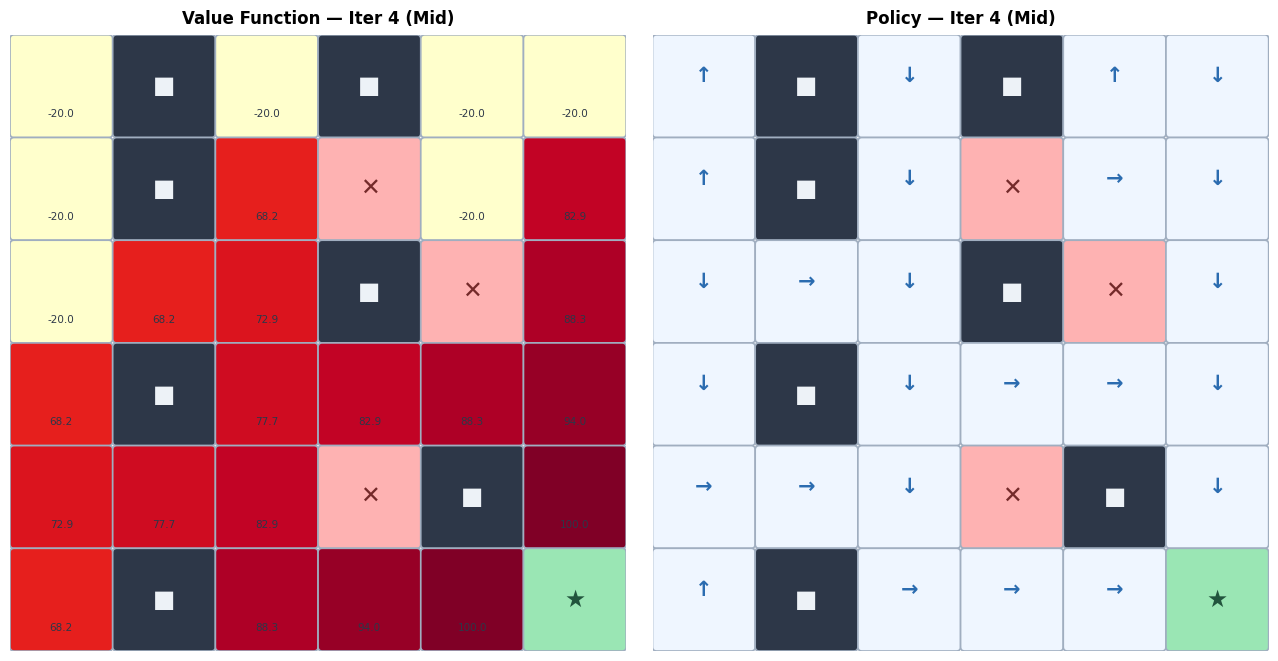

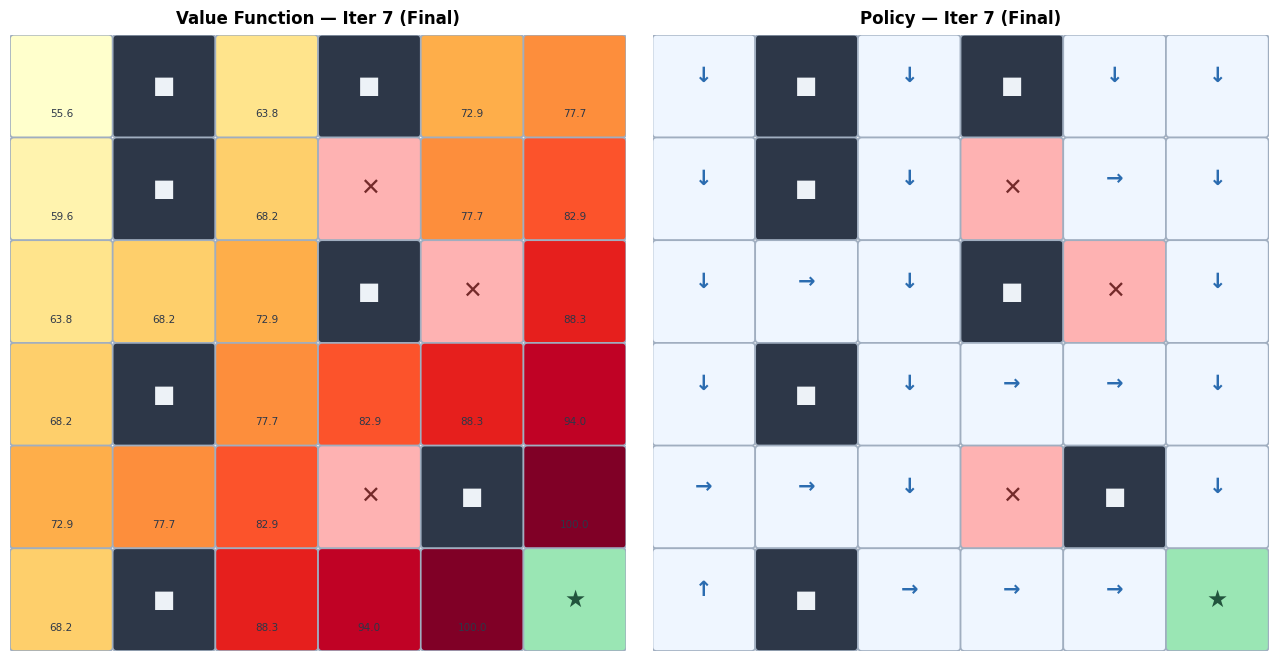

In [ ]:
# ============================================================
# 📽️  Policy Iteration 수렴 과정 확인
# ============================================================
# 각 iteration에서 Value Function과 Policy가 어떻게
# 변화하는지 단계별로 살펴봅니다.
# ============================================================

print(f"총 {len(history_pi)}번의 반복 결과가 저장되어 있습니다.")
print("초기(0) → 중간 → 최종 순서로 변화 과정을 확인합니다.\n")

# 확인할 단계 선택
steps = sorted(set([0, len(history_pi) // 2, len(history_pi) - 1]))

for step in steps:
    V_s, pi_s = history_pi[step]
    label = "Initial" if step == 0 else ("Final" if step == len(history_pi) - 1 else "Mid")
    show_value_and_policy(env_pi, V_s, pi_s, iteration=f"{step} ({label})")


---
# 🟡 Part 2: SARSA (On-Policy TD Learning)

## Policy Iteration과의 핵심 차이: **Model-Free**

Policy Iteration은 환경의 **전이 함수(transition function) T를 미리 알고 있어야** 했습니다.
하지만 현실의 대부분 문제에서는 환경을 완전히 모릅니다.

> 📌 **이해를 돕기 위한 예시**: 미로 지도 없이 직접 돌아다니면서 경험으로 최적 경로를 찾는 방법입니다.

---

## 주요 개념

### 🔹 Q-Function Q(s, a) — 행동 가치 함수
**"상태 s에서 행동 a를 취하고, 이후 최선을 다했을 때 기대되는 총 보상"**

$$Q^\pi(s, a) = R(s, a) + \gamma \cdot Q^\pi(s',\, a')$$

### 🔹 TD (Temporal Difference) 학습 — 시간차 학습
에피소드가 끝날 때까지 기다리지 않고, **매 스텝마다 즉시 학습**합니다:

$$Q(s,a) \;\leftarrow\; Q(s,a) \;+\; \alpha \Bigl[\underbrace{r + \gamma\, Q(s', a')}_{\text{TD Target}} - Q(s,a)\Bigr]$$

- $\alpha$ (alpha, **학습률**): 새 정보를 얼마나 빠르게 반영할지
- $r + \gamma Q(s',a') - Q(s,a)$ 는 **TD Error** — 예측과 실제의 차이

### 🔹 SARSA = **On-Policy**
알고리즘 이름의 의미: **S**tate → **A**ction → **R**eward → next **S**tate → next **A**ction

> 다음 행동 a'를 **실제로 epsilon-greedy로 선택한 행동** 그대로 사용해 Q를 업데이트합니다.
> 즉, **지금 따르고 있는 정책** 그대로 배웁니다 → **On-Policy**

### 🔹 ε-greedy (엡실론-그리디) 탐색 전략

```
확률  ε   → 랜덤 행동    (Exploration: 새로운 경로 탐험)
확률 1−ε  → 최선의 행동  (Exploitation: 알고 있는 최선 선택)
```

학습 초반 ε=1 (완전 탐험) → 점차 감소 → 최적 행동 선택 비율 증가


In [ ]:
# ============================================================
# 🟡 SARSA 알고리즘 구현
# ============================================================

def sarsa(env, episodes=1000, alpha=0.1, gamma=0.99,
          epsilon=1.0, log_interval=100):
    """
    SARSA: On-Policy TD Control

    업데이트 규칙:
        Q(s,a) ← Q(s,a) + α · [ r + γ·Q(s',a') − Q(s,a) ]
                                 ^^^^^^^^^^^^^^^^^^^^
                                 ★ a'는 실제로 선택한 다음 행동 (on-policy)

    Parameters
    ----------
    env          : GridWorldEnv  게임 환경
    episodes     : int           총 학습 에피소드 수
    alpha        : float         학습률 (learning rate)     0 < α ≤ 1
    gamma        : float         할인율 (discount factor)   0 < γ ≤ 1
    epsilon      : float         초기 탐험율 (exploration rate)
    log_interval : int           로그 출력 주기

    Returns
    -------
    Q       : Q-table  {state: {Action: float}}
    policy  : {state: Action}
    rewards : list  에피소드별 총 보상
    """
    # Q-table 초기화: 모든 (상태, 행동) 쌍의 Q값을 0으로 설정
    Q = defaultdict(lambda: {a: 0.0 for a in Action})

    rewards       = []
    success_count = 0
    max_steps     = 200     # 에피소드당 최대 스텝 수 (무한 루프 방지)

    # Epsilon Decay 설정 (탐험율 점진적 감소)
    initial_epsilon = epsilon
    min_epsilon     = 0.05   # 최소 탐험율 (완전히 0이 되면 탐험 불가)
    decay_rate      = 0.99   # 매 에피소드마다 99%로 감소

    for episode in range(episodes):

        # ── Epsilon 감소 ─────────────────────────────────
        epsilon = max(min_epsilon, initial_epsilon * (decay_rate ** episode))

        state = tuple(env.reset())

        # SARSA의 특징: 에피소드 시작 시 첫 행동을 미리 선택
        # (매 스텝에서 (s, a, r, s', a') 쌍을 유지)
        if random.random() < epsilon:
            action = random.choice(list(Action))      # 탐험 (Exploration)
        else:
            action = max(Q[state], key=Q[state].get)  # 활용 (Exploitation)

        done         = False
        total_reward = 0
        steps        = 0

        while not done and steps < max_steps:

            # ── 환경과 상호작용 ─────────────────────────
            next_state, reward, done = env.step(action.value)
            next_state    = tuple(next_state)
            total_reward += reward

            # ── 다음 행동 선택 (epsilon-greedy) ─────────
            # ★ SARSA 핵심: 다음 행동 a'도 epsilon-greedy로 실제 선택!
            if random.random() < epsilon:
                next_action = random.choice(list(Action))
            else:
                next_action = max(Q[next_state], key=Q[next_state].get)

            # ── SARSA Q-value 업데이트 ───────────────────
            # TD Target = r + γ · Q(s', a')
            # (done=True 이면 에피소드 종료 → 미래 가치 = 0)
            td_target = reward + gamma * Q[next_state][next_action] * (not done)
            # TD Error = TD Target - Q(s, a)
            td_error  = td_target - Q[state][action]
            # Q 업데이트: 오차 방향으로 α 만큼 이동
            Q[state][action] += alpha * td_error

            # 다음 스텝으로
            state, action = next_state, next_action
            steps        += 1

        rewards.append(total_reward)
        if reward == 100:
            success_count += 1

        # ── 주기적 로그 출력 ────────────────────────────
        if (episode + 1) % log_interval == 0:
            avg_r = sum(rewards[-log_interval:]) / log_interval
            sr    = success_count / log_interval * 100
            print(f"  [Ep {episode+1:5d}]  ε={epsilon:.3f}  |  "
                  f"Avg Reward: {avg_r:8.1f}  |  Success Rate: {sr:5.1f}%")
            success_count = 0

    # 최종 정책 추출: 각 상태에서 Q값이 가장 큰 행동
    policy = {s: max(q, key=q.get) for s, q in Q.items()}
    return Q, policy, rewards


print("✅ SARSA 함수 정의 완료")


✅ SARSA 함수 정의 완료


  SARSA 실행
  [Ep   200]  ε=0.135  |  Avg Reward:    -25.4  |  Success Rate:  57.0%
  [Ep   400]  ε=0.050  |  Avg Reward:     82.3  |  Success Rate:  96.0%
  [Ep   600]  ε=0.050  |  Avg Reward:     86.5  |  Success Rate:  98.0%
  [Ep   800]  ε=0.050  |  Avg Reward:     80.5  |  Success Rate:  95.0%
  [Ep  1000]  ε=0.050  |  Avg Reward:     87.4  |  Success Rate:  98.5%

🗺️  SARSA 최종 결과


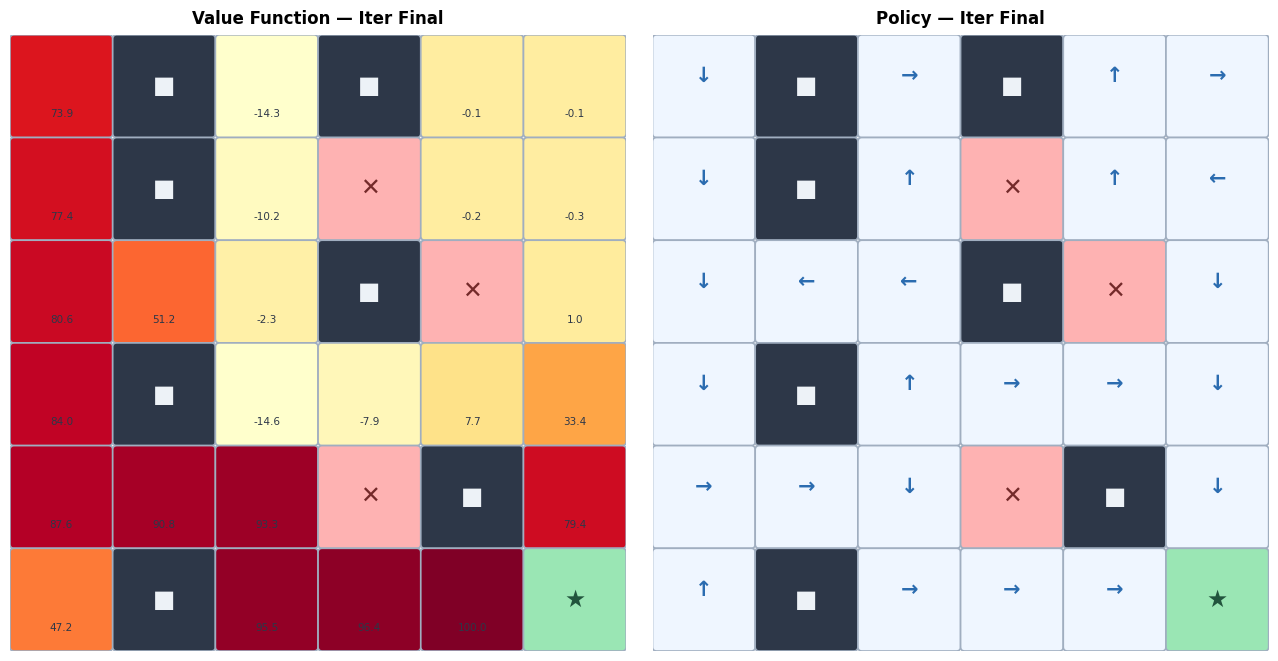

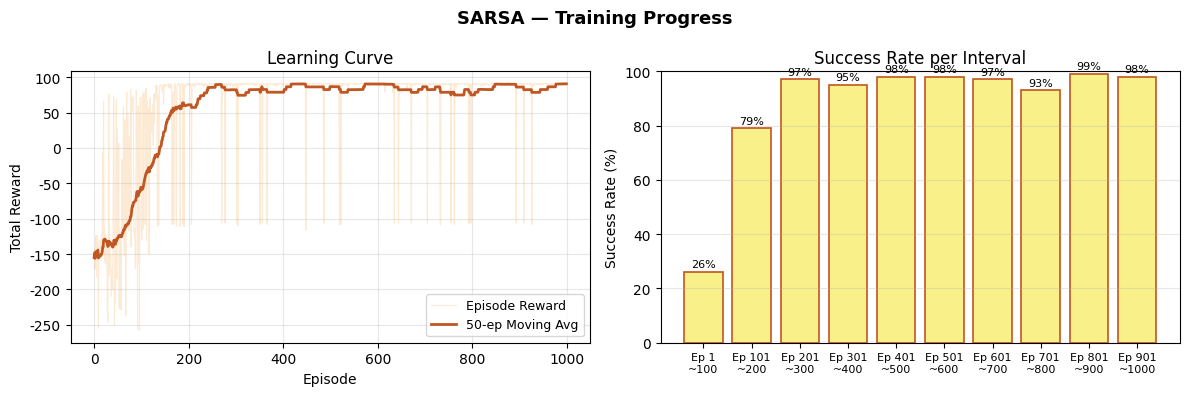

In [ ]:
# ============================================================
# 🚀 SARSA 실행 및 결과 시각화
# ============================================================

print("=" * 55)
print("  SARSA 실행")
print("=" * 55)

random.seed(42)
env_sarsa = GridWorldEnv(map_data=MAP_6)

Q_sarsa, policy_sarsa, rewards_sarsa = sarsa(
    env_sarsa,
    episodes     = 1000,
    alpha        = 0.1,    # 학습률
    gamma        = 0.99,   # 할인율
    epsilon      = 1.0,    # 초기 탐험율 100%
    log_interval = 200
)

# ── Value Function 재구성 & 시각화 ────────────────────────────
V_sarsa = {s: max(Q_sarsa[s].values()) for s in Q_sarsa}
print("\n🗺️  SARSA 최종 결과")
show_value_and_policy(env_sarsa, V_sarsa, policy_sarsa, iteration="Final")

# ── 학습 곡선 시각화 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("SARSA — Training Progress", fontsize=13, fontweight='bold')

# (1) Episode reward + moving average
window = 50
ma_s   = [np.mean(rewards_sarsa[max(0, i - window):i + 1])
          for i in range(len(rewards_sarsa))]

axes[0].plot(rewards_sarsa, alpha=0.25, color='#F6AD55', linewidth=0.8, label='Episode Reward')
axes[0].plot(ma_s, color='#C05621', linewidth=2, label=f'{window}-ep Moving Avg')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Learning Curve')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# (2) 구간별 성공률 막대 그래프
interval = 100
sr_sarsa = [
    sum(1 for r in rewards_sarsa[i:i + interval] if r > 0) / interval * 100
    for i in range(0, len(rewards_sarsa), interval)
]
bars = axes[1].bar(range(len(sr_sarsa)), sr_sarsa,
                   color='#FAF089', edgecolor='#C05621', linewidth=1.2)
axes[1].set_xticks(range(len(sr_sarsa)))
axes[1].set_xticklabels([f'Ep {i*interval+1}\n~{(i+1)*interval}'
                          for i in range(len(sr_sarsa))], fontsize=8)
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_title('Success Rate per Interval')
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3, axis='y')
# 막대 위에 수치 표시
for bar, val in zip(bars, sr_sarsa):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


---
# 🟢 Part 3: Q-Learning (Off-Policy TD Learning)

## SARSA와의 핵심 차이: **Off-Policy**

SARSA와 Q-Learning은 매우 유사하지만, Q값 업데이트 방식에서 **결정적인 차이**가 있습니다.

| 항목 | SARSA | Q-Learning |
|:----:|-------|-----------|
| 업데이트 기준 | 실제 선택한 a' | **가상의 최선 행동** max Q(s',·) |
| Policy 유형 | On-Policy | **Off-Policy** |
| 특성 | 보수적, 안전한 경로 선호 | 공격적, 이론적 최적 추구 |

---

## Q-Learning 업데이트 규칙

$$Q(s,a) \;\leftarrow\; Q(s,a) \;+\; \alpha \Bigl[ r + \gamma \cdot \underbrace{\max_{a'}Q(s', a')}_{\text{★ 실제 선택과 무관}} - Q(s,a) \Bigr]$$

> 💡 **핵심**: epsilon-greedy로 행동하면서도, Q 업데이트는 **항상 최선의 행동**을 기준으로 합니다.
> 행동하는 정책(behavior policy)과 학습하는 정책(target policy)이 다릅니다 → **Off-Policy**의 의미입니다.

## SARSA vs Q-Learning — 코드 비교

```python
# SARSA  (on-policy)
td_target = reward + gamma * Q[next_state][next_action]   # ← 실제 선택한 next_action

# Q-Learning  (off-policy)
td_target = reward + gamma * max(Q[next_state].values())  # ← 가장 좋은 Q값 (max)
```

**딱 한 줄 차이지만, 학습된 정책의 특성이 달라집니다!**


In [ ]:
# ============================================================
# 🟢 Q-Learning 알고리즘 구현
# ============================================================

def q_learning(env, episodes=1000, alpha=0.1, gamma=0.99,
               epsilon=1.0, log_interval=100):
    """
    Q-Learning: Off-Policy TD Control

    업데이트 규칙:
        Q(s,a) ← Q(s,a) + α · [ r + γ·max_a' Q(s',a') − Q(s,a) ]
                                  ^^^^^^^^^^^^^^^^^^^^
                                  ★ 실제 선택과 무관하게 최대 Q값 사용 (off-policy)

    SARSA와의 비교:
        SARSA:      td_target = r + γ · Q(s', 실제_선택한_a')    ← on-policy
        Q-Learning: td_target = r + γ · max_a' Q(s', a')         ← off-policy
    """
    Q = defaultdict(lambda: {a: 0.0 for a in Action})

    rewards       = []
    success_count = 0
    max_steps     = 200

    initial_epsilon = epsilon
    min_epsilon     = 0.05
    decay_rate      = 0.99

    for episode in range(episodes):

        epsilon  = max(min_epsilon, initial_epsilon * (decay_rate ** episode))
        state    = tuple(env.reset())
        done     = False
        total_reward = 0
        steps    = 0

        while not done and steps < max_steps:

            # ── Epsilon-Greedy 행동 선택 ─────────────────
            if random.random() < epsilon:
                action = random.choice(list(Action))       # 탐험
            else:
                action = max(Q[state], key=Q[state].get)   # 활용

            next_state, reward, done = env.step(action.value)
            next_state    = tuple(next_state)
            total_reward += reward

            # ── Q-Learning 업데이트 ──────────────────────
            # ★ Q-Learning 핵심: 다음 행동을 실제로 선택하지 않고
            #    max Q(s', a') 를 바로 사용합니다
            max_next_q = max(Q[next_state].values())  # 다음 상태의 최대 Q값
            td_target  = reward + gamma * max_next_q * (not done)
            td_error   = td_target - Q[state][action]
            Q[state][action] += alpha * td_error

            state = next_state
            steps += 1

        rewards.append(total_reward)
        if reward == 100:
            success_count += 1

        if (episode + 1) % log_interval == 0:
            avg_r = sum(rewards[-log_interval:]) / log_interval
            sr    = success_count / log_interval * 100
            print(f"  [Ep {episode+1:5d}]  ε={epsilon:.3f}  |  "
                  f"Avg Reward: {avg_r:8.1f}  |  Success Rate: {sr:5.1f}%")
            success_count = 0

    policy = {s: max(q, key=q.get) for s, q in Q.items()}
    return Q, policy, rewards


print("✅ Q-Learning 함수 정의 완료")


✅ Q-Learning 함수 정의 완료


  Q-Learning 실행
  [Ep   200]  ε=0.135  |  Avg Reward:     -6.7  |  Success Rate:  56.5%
  [Ep   400]  ε=0.050  |  Avg Reward:     86.2  |  Success Rate:  98.0%
  [Ep   600]  ε=0.050  |  Avg Reward:     85.4  |  Success Rate:  97.5%
  [Ep   800]  ε=0.050  |  Avg Reward:     83.6  |  Success Rate:  96.5%
  [Ep  1000]  ε=0.050  |  Avg Reward:     81.5  |  Success Rate:  95.5%

🗺️  Q-Learning 최종 결과


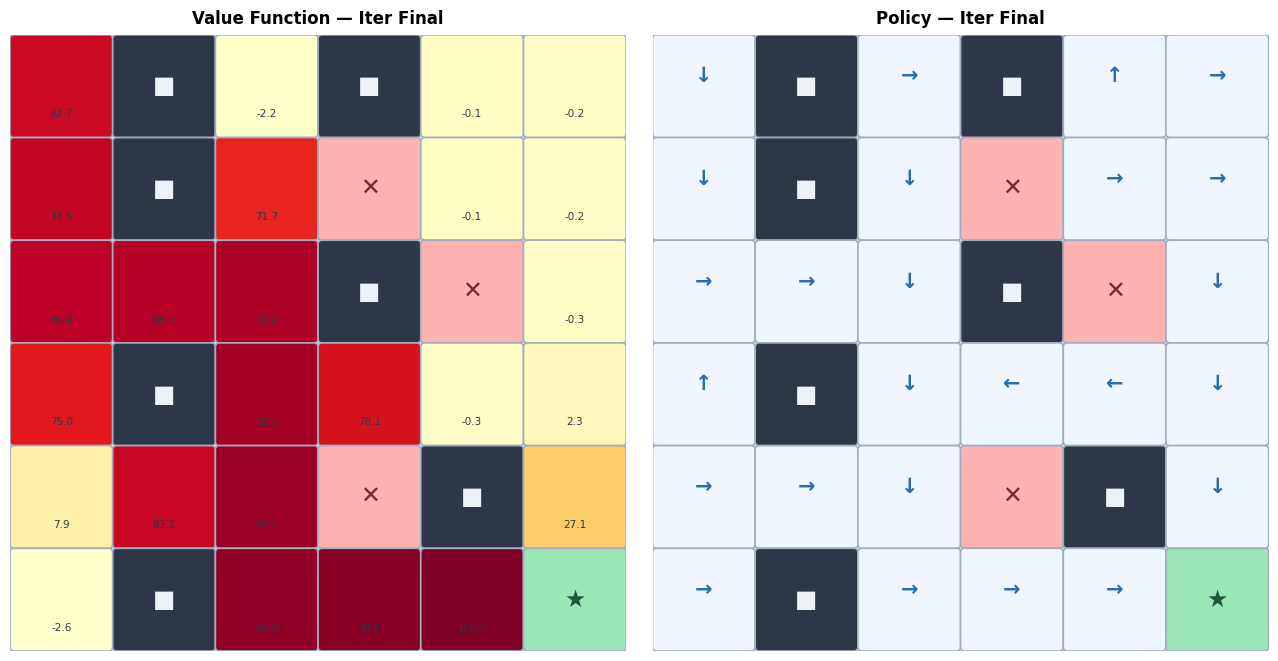


📊 SARSA vs Q-Learning 학습 곡선 비교


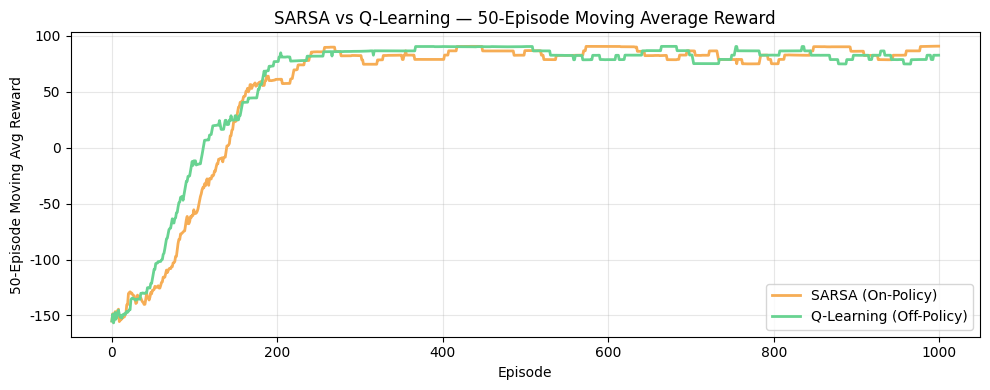

In [ ]:
# ============================================================
# 🚀 Q-Learning 실행 및 SARSA 비교 시각화
# ============================================================

print("=" * 55)
print("  Q-Learning 실행")
print("=" * 55)

random.seed(42)
env_ql = GridWorldEnv(map_data=MAP_6)

Q_ql, policy_ql, rewards_ql = q_learning(
    env_ql,
    episodes     = 1000,
    alpha        = 0.1,
    gamma        = 0.99,
    epsilon      = 1.0,
    log_interval = 200
)

V_ql = {s: max(Q_ql[s].values()) for s in Q_ql}
print("\n🗺️  Q-Learning 최종 결과")
show_value_and_policy(env_ql, V_ql, policy_ql, iteration="Final")

# ── SARSA vs Q-Learning 학습 곡선 비교 ───────────────────────
print("\n📊 SARSA vs Q-Learning 학습 곡선 비교")
window = 50
ma_sarsa = [np.mean(rewards_sarsa[max(0, i-window):i+1]) for i in range(len(rewards_sarsa))]
ma_ql    = [np.mean(rewards_ql   [max(0, i-window):i+1]) for i in range(len(rewards_ql))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ma_sarsa, color='#F6AD55', linewidth=2, label='SARSA (On-Policy)')
ax.plot(ma_ql,    color='#68D391', linewidth=2, label='Q-Learning (Off-Policy)')
ax.set_xlabel('Episode')
ax.set_ylabel(f'{window}-Episode Moving Avg Reward')
ax.set_title(f'SARSA vs Q-Learning — {window}-Episode Moving Average Reward')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
# 🔴 Part 4: Cliff World — SARSA vs Q-Learning 비교

## 왜 Cliff World인가?

Cliff World는 SARSA와 Q-Learning의 **On-Policy vs Off-Policy 차이**를 가장 직관적으로 보여주는 고전 예제입니다.

```
행(row) 0  [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ]
행(row) 1  [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ]
행(row) 2  [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ] [ ]
행(row) 3  [S] [C] [C] [C] [C] [C] [C] [C] [C] [C] [C] [G]
           ↑   ←----─ CLIFF (절벽, -100) ──-─→  ↑
           시작                                        목표
```

- **S**: 시작 지점 (왼쪽 아래, (3, 0))
- **G**: 목표 지점 (오른쪽 아래, (3, 11))
- **C**: 절벽 — 밟으면 -100 패널티 후 시작 지점으로 복귀

---

## 예상 결과

| 알고리즘 | 선택 경로 | 이유 |
|---------|----------|------|
| **SARSA** (On-Policy) | 위쪽 안전 경로 🛡️ | 탐험 중 실수로 절벽을 밟는 경험을 함 → 안전 거리 확보 |
| **Q-Learning** (Off-Policy) | 절벽 바로 위 최단 경로 ⚡ | max Q로만 계산 → 이론적 최적(절벽 바로 위)을 학습 |

> 💡 **핵심**: On-Policy는 실제 탐험의 위험을 학습에 반영하므로 더 안전합니다.
> Off-Policy는 이론적 최적을 추구하지만, 탐험 중에는 더 위험할 수 있습니다.


📍 Cliff World (4×12) 맵 미리보기


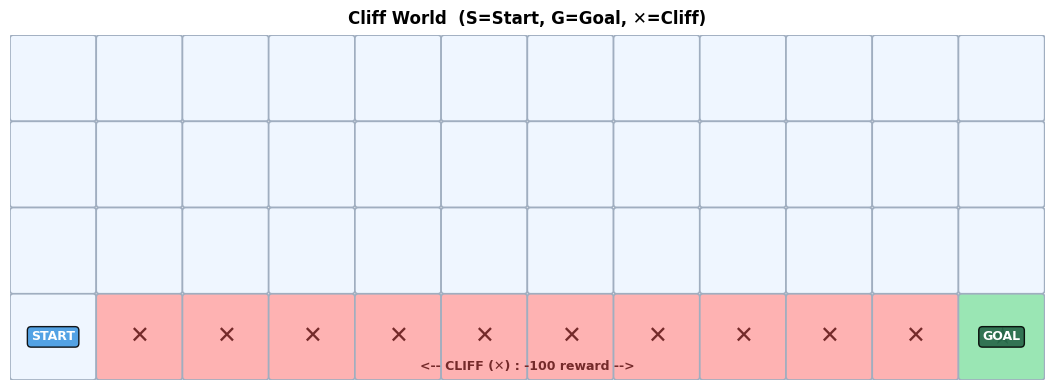

In [ ]:
# ============================================================
# 🔴 Cliff World 환경 정의
# ============================================================
# 4×12 격자:
#   - 시작: (3, 0) — 왼쪽 아래
#   - 목표: (3, 11) — 오른쪽 아래
#   - 절벽: (3, 1) ~ (3, 10) — 아랫줄 가운데
# ============================================================

class CliffEnv(GridWorldEnv):
    """
    Cliff Walking 환경
    시작 위치가 왼쪽 아래 (height-1, 0)인 점이
    일반 GridWorldEnv와 다릅니다.
    """
    def reset(self):
        # ★ 시작 위치: 왼쪽 아래 (3, 0)
        self.agent_pos = [self.height - 1, 0]
        self.done      = False
        return self.agent_pos[:]


def make_cliff():
    """4×12 Cliff World 환경을 생성합니다."""
    rows, cols = 4, 12
    map_data   = {
        "width":  cols,
        "height": rows,
        "walls":  [],
        # 절벽: 아랫줄 가운데 (cols-2개)
        "traps":  [[rows - 1, c] for c in range(1, cols - 1)],
        "goal":   [rows - 1, cols - 1]
    }
    return CliffEnv(map_data=map_data)


# ── Cliff World 맵 미리보기 ──────────────────────────────────
print("📍 Cliff World (4×12) 맵 미리보기")
_env_cliff = make_cliff()

fig, ax = plt.subplots(figsize=(13, 4))
render_grid(_env_cliff, ax, title="Cliff World  (S=Start, G=Goal, ✕=Cliff)")

# Start / Goal labels
ax.text(0, 3, 'START', ha='center', va='center', fontsize=9,
        fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#4299E1', alpha=0.9))
ax.text(11, 3, 'GOAL', ha='center', va='center', fontsize=9,
        fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#276749', alpha=0.9))
ax.text(5.5, 3.42, '<-- CLIFF (✕) : -100 reward -->', ha='center', va='bottom',
        fontsize=9, color='#742A2A', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 🚀 Cliff World: SARSA vs Q-Learning 학습
# ============================================================

CLIFF_EPISODES    = 500
CLIFF_ALPHA       = 0.1
CLIFF_GAMMA       = 0.99
CLIFF_EPSILON     = 1.0
CLIFF_LOG         = 100

print("=" * 55)
print("  Cliff World: SARSA vs Q-Learning 비교 실험")
print("=" * 55)

# ── SARSA ────────────────────────────────────────────────────
print("\n[1/2] SARSA 학습 중...")
random.seed(0)
env_c_sarsa = make_cliff()
Q_cs, policy_cs, rewards_cs = sarsa(
    env_c_sarsa,
    episodes     = CLIFF_EPISODES,
    alpha        = CLIFF_ALPHA,
    gamma        = CLIFF_GAMMA,
    epsilon      = CLIFF_EPSILON,
    log_interval = CLIFF_LOG
)

# ── Q-Learning ───────────────────────────────────────────────
print("\n[2/2] Q-Learning 학습 중...")
random.seed(0)
env_c_ql = make_cliff()
Q_cql, policy_cql, rewards_cql = q_learning(
    env_c_ql,
    episodes     = CLIFF_EPISODES,
    alpha        = CLIFF_ALPHA,
    gamma        = CLIFF_GAMMA,
    epsilon      = CLIFF_EPSILON,
    log_interval = CLIFF_LOG
)

print("\n✅ 두 알고리즘 학습 완료!")


  Cliff World: SARSA vs Q-Learning 비교 실험

[1/2] SARSA 학습 중...
  [Ep   100]  ε=0.370  |  Avg Reward:    -99.7  |  Success Rate:  14.0%
  [Ep   200]  ε=0.135  |  Avg Reward:     41.0  |  Success Rate:  84.0%
  [Ep   300]  ε=0.050  |  Avg Reward:     73.0  |  Success Rate:  94.0%
  [Ep   400]  ε=0.050  |  Avg Reward:     84.9  |  Success Rate: 100.0%
  [Ep   500]  ε=0.050  |  Avg Reward:     81.3  |  Success Rate:  98.0%

[2/2] Q-Learning 학습 중...
  [Ep   100]  ε=0.370  |  Avg Reward:   -109.7  |  Success Rate:   6.0%
  [Ep   200]  ε=0.135  |  Avg Reward:    -16.7  |  Success Rate:  52.0%
  [Ep   300]  ε=0.050  |  Avg Reward:     44.3  |  Success Rate:  78.0%
  [Ep   400]  ε=0.050  |  Avg Reward:     56.3  |  Success Rate:  84.0%
  [Ep   500]  ε=0.050  |  Avg Reward:     56.2  |  Success Rate:  84.0%

✅ 두 알고리즘 학습 완료!


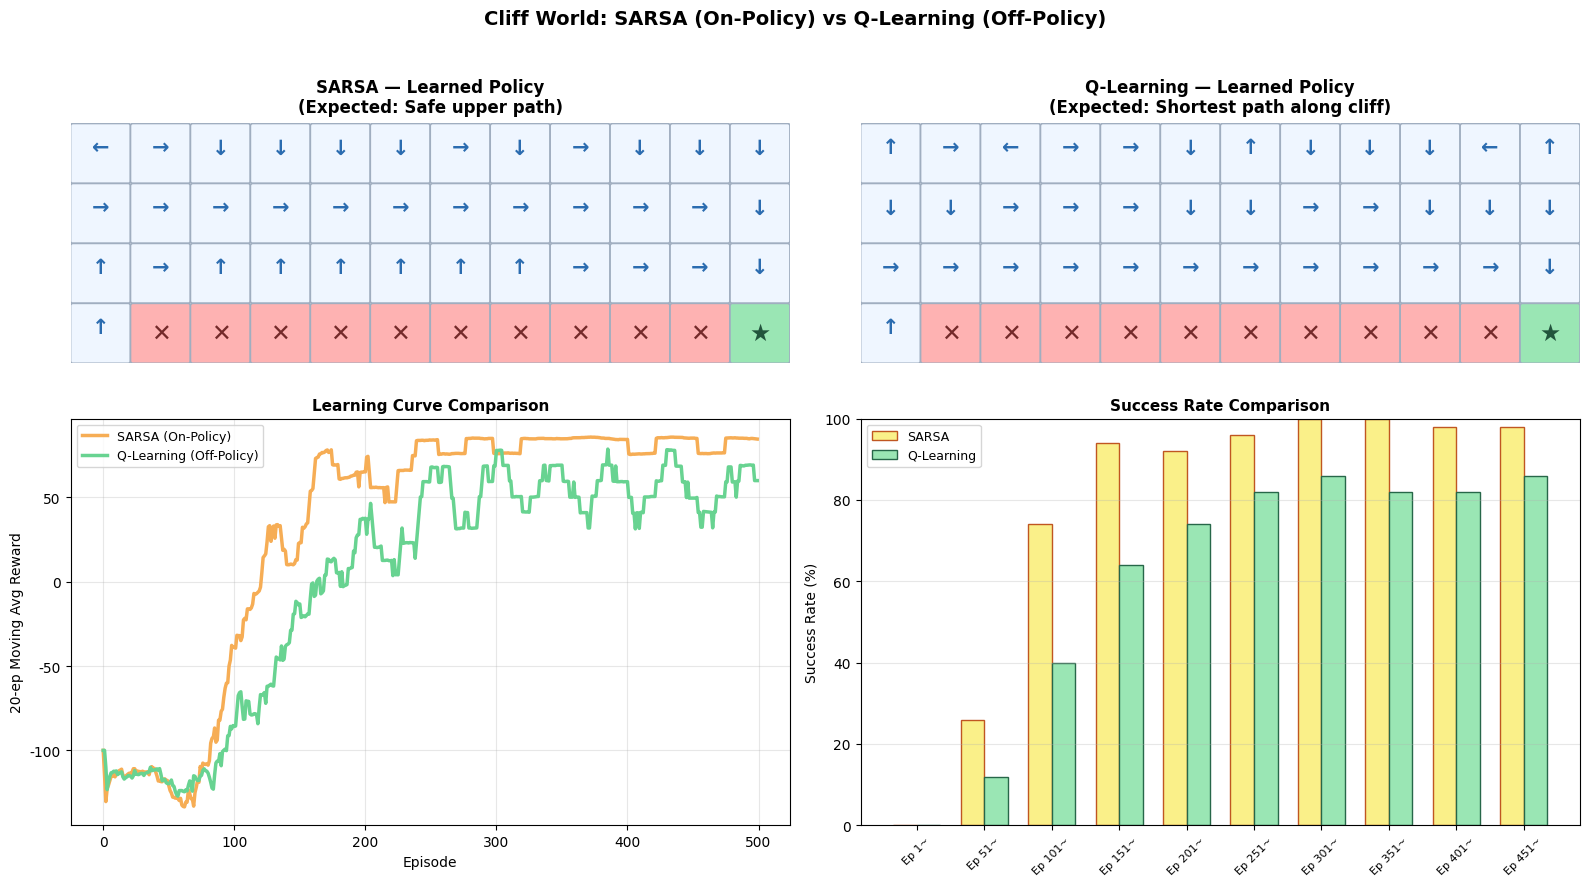


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 결과 해석 (Interpretation)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🟡 SARSA (On-Policy)
   → 학습 중 epsilon-greedy 행동으로 실제로 절벽을 밟는 경험을 합니다.
   → 그 패널티를 Q값에 직접 반영하므로, 절벽에서 멀리 떨어진
     '안전한 위쪽 경로' 를 선호하게 됩니다.
   → 학습 중 평균 보상이 Q-Learning보다 낮을 수 있습니다 (절벽 회피).

🟢 Q-Learning (Off-Policy)
   → max Q(s',·) 로만 업데이트하므로, 이론적으로는
     절벽 바로 위의 '최단 경로' 가 최적임을 학습합니다.
   → 하지만 탐험(ε>0) 중에는 절벽에 자주 빠져 에피소드 보상이 낮습니다.
   → 수렴된 정책 자체는 더 짧은 (이론적 최적) 경로를 선택합니다.

💡 요약:
   • 실제로 따르는 정책이 안전해야 한다면     → SARSA
   • 이론적 최적 정책을 빠르게 학습하려면      → Q-Learning
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [ ]:
# ============================================================
# 📊 Cliff World 비교 시각화
# ============================================================

fig = plt.figure(figsize=(16, 9))
fig.suptitle("Cliff World: SARSA (On-Policy) vs Q-Learning (Off-Policy)",
             fontsize=14, fontweight='bold', y=0.98)

# ── (1) SARSA Policy ─────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
render_grid(make_cliff(), ax1, policy=policy_cs,
            title="SARSA — Learned Policy\n(Expected: Safe upper path)",
            show_value=False, show_policy=True)

# ── (2) Q-Learning Policy ────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
render_grid(make_cliff(), ax2, policy=policy_cql,
            title="Q-Learning — Learned Policy\n(Expected: Shortest path along cliff)",
            show_value=False, show_policy=True)

# ── (3) 학습 곡선 비교 ───────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
window = 20
ma_cs  = [np.mean(rewards_cs [max(0,i-window):i+1]) for i in range(len(rewards_cs))]
ma_cql = [np.mean(rewards_cql[max(0,i-window):i+1]) for i in range(len(rewards_cql))]

ax3.plot(ma_cs,  color='#F6AD55', linewidth=2.5, label='SARSA (On-Policy)')
ax3.plot(ma_cql, color='#68D391', linewidth=2.5, label='Q-Learning (Off-Policy)')
ax3.set_xlabel('Episode', fontsize=10)
ax3.set_ylabel(f'{window}-ep Moving Avg Reward', fontsize=10)
ax3.set_title('Learning Curve Comparison', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── (4) 구간별 성공률 비교 ───────────────────────────────────
ax4  = fig.add_subplot(2, 2, 4)
itvl = 50
sr_cs  = [sum(1 for r in rewards_cs [i:i+itvl] if r > 0) / itvl * 100
          for i in range(0, len(rewards_cs),  itvl)]
sr_cql = [sum(1 for r in rewards_cql[i:i+itvl] if r > 0) / itvl * 100
          for i in range(0, len(rewards_cql), itvl)]

x  = np.arange(len(sr_cs))
bw = 0.35
ax4.bar(x - bw/2, sr_cs,  bw, color='#FAF089', edgecolor='#C05621', linewidth=1, label='SARSA')
ax4.bar(x + bw/2, sr_cql, bw, color='#9AE6B4', edgecolor='#276749', linewidth=1, label='Q-Learning')
ax4.set_xticks(x)
ax4.set_xticklabels([f'Ep {i*itvl+1}~' for i in range(len(sr_cs))],
                     rotation=45, fontsize=8)
ax4.set_ylabel('Success Rate (%)', fontsize=10)
ax4.set_title('Success Rate Comparison', fontsize=11, fontweight='bold')
ax4.set_ylim(0, 100)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 해설 출력 ──────────────────────────────────────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 결과 해석 (Interpretation)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🟡 SARSA (On-Policy)
   → 학습 중 epsilon-greedy 행동으로 실제로 절벽을 밟는 경험을 합니다.
   → 그 패널티를 Q값에 직접 반영하므로, 절벽에서 멀리 떨어진
     '안전한 위쪽 경로' 를 선호하게 됩니다.
   → 학습 중 평균 보상이 Q-Learning보다 낮을 수 있습니다 (절벽 회피).

🟢 Q-Learning (Off-Policy)
   → max Q(s',·) 로만 업데이트하므로, 이론적으로는
     절벽 바로 위의 '최단 경로' 가 최적임을 학습합니다.
   → 하지만 탐험(ε>0) 중에는 절벽에 자주 빠져 에피소드 보상이 낮습니다.
   → 수렴된 정책 자체는 더 짧은 (이론적 최적) 경로를 선택합니다.

💡 요약:
   • 실제로 따르는 정책이 안전해야 한다면     → SARSA
   • 이론적 최적 정책을 빠르게 학습하려면      → Q-Learning
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


---
# 🎉 전체 내용 요약

## 알고리즘 비교표

| 항목 | Policy Iteration | SARSA | Q-Learning |
|:----:|:---------------:|:-----:|:----------:|
| **분류** | Dynamic Programming | Model-Free TD | Model-Free TD |
| **환경 model 필요** | ✅ 필요 | ❌ 불필요 | ❌ 불필요 |
| **Policy 유형** | — | On-Policy | Off-Policy |
| **업데이트 기준** | Bellman Sweep* | r + γ·Q(s',**a'**) | r + γ·**max** Q(s',·) |
| **탐험(Exploration) 전략** | 없음 (완전 계산) | ε-greedy | ε-greedy |
| **특성** | 수렴 보장, 빠름 | 안전, 보수적 | 이론적 최적 추구 |

---
\* 상태 공간(State Space) 전체를 한 번 훑으며(sweep) 가치 함수(Value Function)를 업데이트

## 핵심 정리 3줄 요약

1. **환경 모델(environment model)을 완전히 알고 있다면** → Policy Iteration (DP): 빠르고 최적이 보장됩니다.
2. **환경을 모르고 안전이 중요하다면** → SARSA (On-Policy): 탐험의 위험까지 반영합니다.
3. **환경을 모르고 최적 경로가 중요하다면** → Q-Learning (Off-Policy): 이론적 최적에 수렴합니다.

> 🔑 현실 문제의 대부분은 환경 모델이 없으므로, SARSA와 Q-Learning 같은 **Model-Free** 방법이 더 널리 활용됩니다.

---
